# Voronoi analysis: Bicycle thefts vs TTS bike usage

This notebook demonstrates how to build clipped Voronoi (Thiessen) polygons from bicycle-theft point locations, join Transportation Tomorrow Survey (TTS) bike-usage data to the polygons, compute theft rates, and visualize results. It also shows how to refactor notebook code into a reusable script under src/bikespace_data/bicycle_theft.

Datasets used:
- Bicycle thefts: bicycle_theft/output_files/bicycle-thefts-normalized.geojson
- TTS: provide a CSV (or GeoJSON) from the School of Cities TTS repo (set `tts_trips_csv_url` variable below)

Outputs saved to: notebooks/output/voronoi_theft/


In [1]:
# Setup imports and environment checks
import sys
import os
from pathlib import Path
import warnings

import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import MultiPoint, Point, Polygon
from shapely.ops import voronoi_diagram

# SciPy fallback
try:
    from scipy.spatial import Voronoi
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

import matplotlib.pyplot as plt
import contextily as ctx

print(f"Python: {sys.version}")
print(f"GeoPandas: {gpd.__version__}")
import shapely
print(f"Shapely: {shapely.__version__}, voronoi_diagram available: {'voronoi_diagram' in dir(shapely.ops)}")
print(f"SciPy available: {SCIPY_AVAILABLE}")

# create an output dir for notebook artifacts
OUT_DIR = Path("notebooks/output/voronoi_theft").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)


Python: 3.12.12 (main, Dec 17 2025, 21:10:06) [Clang 21.1.4 ]
GeoPandas: 1.1.1
Shapely: 2.1.1, voronoi_diagram available: True
SciPy available: True


In [14]:
# Parameters to set
# Default thefts path is where our updater writes normalized output
THEFTS_PATH = Path("bicycle_theft/output_files/bicycle-thefts-normalized.geojson")
# For the initial heatmap we'll use the zone-level GeoJSON (faster) from the School of Cities repo
TTS_TRIPS_CSV_URL = ""
TTS_TRIPS_SOURCE = "https://raw.githubusercontent.com/schoolofcities/transportation-tomorrow-survey/main/data/tts2022zones_data.geojson"
# Optional city boundary file; if None we’ll use a buffered convex hull of thefts as clip polygon
CITY_BOUNDARY_PATH = None

In [3]:
def load_thefts(path: Path = THEFTS_PATH) -> gpd.GeoDataFrame:
    """Load thefts GeoJSON and ensure a proper CRS (EPSG:4326)."""
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        gdf.set_crs(epsg=4326, inplace=True)
    else:
        gdf = gdf.to_crs(epsg=4326)
    print(f"Loaded {len(gdf)} theft records")
    return gdf


def load_tts_trips_csv(url: str | None = None, path: Path | None = None, mode_col: str = "MODE") -> gpd.GeoDataFrame:
    """Load TTS trips CSV and filter to bicycle trips.

    Expect the CSV to contain columns with coordinates (origin/destination). You may need to adapt the column names.
    """
    if url:
        print(f"Reading TTS CSV from {url} ...")
        df = pd.read_csv(url)
    elif path:
        df = pd.read_csv(path)
    else:
        raise ValueError("Provide either a url or local path for TTS trips CSV")

    # Example expected columns: ORIGIN_X, ORIGIN_Y, MODE (adjust as needed)
    possible_x = [c for c in df.columns if "ORIGIN_X" in c.upper() or "X" == c.upper() or "LON" in c.upper() or "LONG" in c.upper()]
    possible_y = [c for c in df.columns if "ORIGIN_Y" in c.upper() or "Y" == c.upper() or "LAT" in c.upper()]

    # Filter to bike modes -- user may need to adapt mode filters
    if mode_col in df.columns:
        bike_df = df[df[mode_col].astype(str).str.lower().isin(["bike","bicycle"])].copy()
    else:
        print("Warning: mode column not found; using full dataset and will filter externally")
        bike_df = df.copy()

    if possible_x and possible_y:
        xcol = possible_x[0]
        ycol = possible_y[0]
        bike_df[xcol] = pd.to_numeric(bike_df[xcol], errors="coerce")
        bike_df[ycol] = pd.to_numeric(bike_df[ycol], errors="coerce")
        bike_df = bike_df.dropna(subset=[xcol,ycol])
        gdf = gpd.GeoDataFrame(bike_df, geometry=gpd.points_from_xy(bike_df[xcol], bike_df[ycol]), crs="EPSG:4326")
        print(f"Loaded {len(gdf)} bike trip points")
        return gdf
    else:
        print("No coordinate columns detected in TTS CSV; returning empty GeoDataFrame")
        return gpd.GeoDataFrame(bike_df)


In [4]:
def build_voronoi_shapely(points_gdf: gpd.GeoDataFrame, clip_polygon: Polygon | None = None) -> gpd.GeoDataFrame:
    """Build Voronoi polygons using shapely.ops.voronoi_diagram and clip to clip_polygon (if provided)."""
    pts = [pt for pt in points_gdf.geometry if pt is not None]
    if len(pts) == 0:
        return gpd.GeoDataFrame(columns=["geometry"])
    mp = MultiPoint(pts)
    # If no clip polygon provided, build one from convex hull buffered slightly
    if clip_polygon is None:
        clip_polygon = mp.convex_hull.buffer(0.01)
    try:
        vor_geom = voronoi_diagram(mp, envelope=clip_polygon)
    except Exception as e:
        raise RuntimeError("shapely.voronoi_diagram failed") from e
    polys = [g for g in vor_geom.geoms] if hasattr(vor_geom, 'geoms') else [vor_geom]
    vor_gdf = gpd.GeoDataFrame(geometry=polys, crs="EPSG:4326")
    # clip to polygon
    vor_gdf = gpd.overlay(vor_gdf, gpd.GeoDataFrame(geometry=[clip_polygon], crs="EPSG:4326"), how="intersection")
    return vor_gdf


def build_voronoi_scipy(points_gdf: gpd.GeoDataFrame, clip_polygon: Polygon | None = None) -> gpd.GeoDataFrame:
    """Fallback Voronoi using scipy.spatial.Voronoi. Returns clipped polygons in EPSG:4326."""
    if not SCIPY_AVAILABLE:
        raise RuntimeError("SciPy is not available in this environment")
    coords = np.array([[p.x, p.y] for p in points_gdf.geometry if p is not None])
    if coords.shape[0] == 0:
        return gpd.GeoDataFrame(columns=["geometry"])
    if clip_polygon is None:
        clip_polygon = MultiPoint(list(points_gdf.geometry)).convex_hull.buffer(0.01)
    vor = Voronoi(coords)
    # Build polygons for each point from regions; handle infinite regions via clipping
    from shapely.ops import polygonize
    polys = []
    for pt_idx, region_idx in enumerate(vor.point_region):
        vertices = vor.regions[region_idx]
        if -1 in vertices or len(vertices) == 0:
            # infinite region -> approximate by buffering point and intersecting with clip
            poly = Point(coords[pt_idx]).buffer(0.05)
        else:
            poly = Polygon(vor.vertices[vertices])
        poly = poly.intersection(clip_polygon)
        polys.append(poly)
    vor_gdf = gpd.GeoDataFrame(geometry=polys, crs="EPSG:4326")
    return vor_gdf


In [ ]:
def aggregate_to_voronoi(vor_gdf: gpd.GeoDataFrame, thefts_gdf: gpd.GeoDataFrame, tts_gdf: gpd.GeoDataFrame, tts_weight_col: str | None = None) -> gpd.GeoDataFrame:
    """Spatially join thefts and TTS trips/zones to voronoi polygons and compute counts and rates.

    If `tts_weight_col` is provided and present in `tts_gdf`, this function will sum that column per polygon
    (useful when TTS is provided as zones with a 'TTS2022' trips count). Otherwise it counts points.
    """
    # ensure spatial index
    vor_gdf = vor_gdf.reset_index(drop=True).copy()
    vor_gdf["vor_id"] = range(len(vor_gdf))

    # ensure CRS alignment (convert inputs to vor_gdf CRS)
    if isinstance(thefts_gdf, gpd.GeoDataFrame) and not thefts_gdf.empty:
        if thefts_gdf.crs != vor_gdf.crs:
            thefts_gdf = thefts_gdf.to_crs(vor_gdf.crs)

    if isinstance(tts_gdf, gpd.GeoDataFrame) and not tts_gdf.empty:
        if tts_gdf.crs != vor_gdf.crs:
            tts_gdf = tts_gdf.to_crs(vor_gdf.crs)

    # theft counts (points within polygons)
    if len(thefts_gdf) > 0:
        t_join = gpd.sjoin(thefts_gdf, vor_gdf, predicate="within", how="left")
        theft_counts = t_join.groupby("vor_id").size().rename("theft_count")
    else:
        theft_counts = pd.Series(dtype=int, name='theft_count')

    # tts counts or weighted sum (use intersects to capture zone centroids / boundary cases)
    if len(tts_gdf) > 0:
        if tts_weight_col and tts_weight_col in tts_gdf.columns:
            u_join = gpd.sjoin(tts_gdf, vor_gdf, predicate="intersects", how="left")
            # sum the weight column per vor_id
            usage_counts = u_join.groupby("vor_id")[tts_weight_col].sum().rename("bike_trips")
        else:
            u_join = gpd.sjoin(tts_gdf, vor_gdf, predicate="intersects", how="left")
            usage_counts = u_join.groupby("vor_id").size().rename("bike_trips")
    else:
        usage_counts = pd.Series(dtype=int, name='bike_trips')

    result = vor_gdf.merge(theft_counts, left_on="vor_id", right_index=True, how="left")
    result = result.merge(usage_counts, left_on="vor_id", right_index=True, how="left")
    result["theft_count"] = result["theft_count"].fillna(0).astype(int)
    # bike_trips may be floats if summed; fillna -> 0
    result["bike_trips"] = result["bike_trips"].fillna(0)

    # rate per 1000 trips
    result["theft_per_1000_trips"] = (result["theft_count"] / result["bike_trips"].replace({0: pd.NA})) * 1000
    return result

vor_rates: rows= 3000
vor_rates CRS: EPSG:4326
thefts (th_gdf) CRS: EPSG:4326 bounds: [-79.62222578  43.58737945 -79.12204396  43.83723693]
tts CRS: EPSG:4326 bounds: [-81.14038  42.83557 -77.64002  44.98661]
vor bounds: [-79.60858307  43.578555   -79.11767275  43.84171205]
polygons with theft_count>0: 3000
polygons with bike_trips>0: 25
bike_trips total: 615161.0 theft_count total: 134455
Top 10 rates (non-NA):
      theft_count  bike_trips theft_per_1000_trips
2578        15145     68174.0            222.15214
1951        15145     68174.0            222.15214
2674         2438     34342.0            70.991788
627            61      1393.0             43.79038
1127           58      1627.0            35.648433
2999          694     19776.0            35.093042
1203          161      6412.0             25.10917
15            130      6412.0            20.274485
1494          560     28604.0            19.577681
585           557     28624.0            19.459195
Top polygon centroid (l

/tmp/ipykernel_246996/2451653233.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  top_idx = vor_rates['theft_per_1000_trips'].fillna(-1).idxmax()
/tmp/ipykernel_246996/2451653233.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_col = vor_rates['theft_per_1000_trips'].fillna(0)


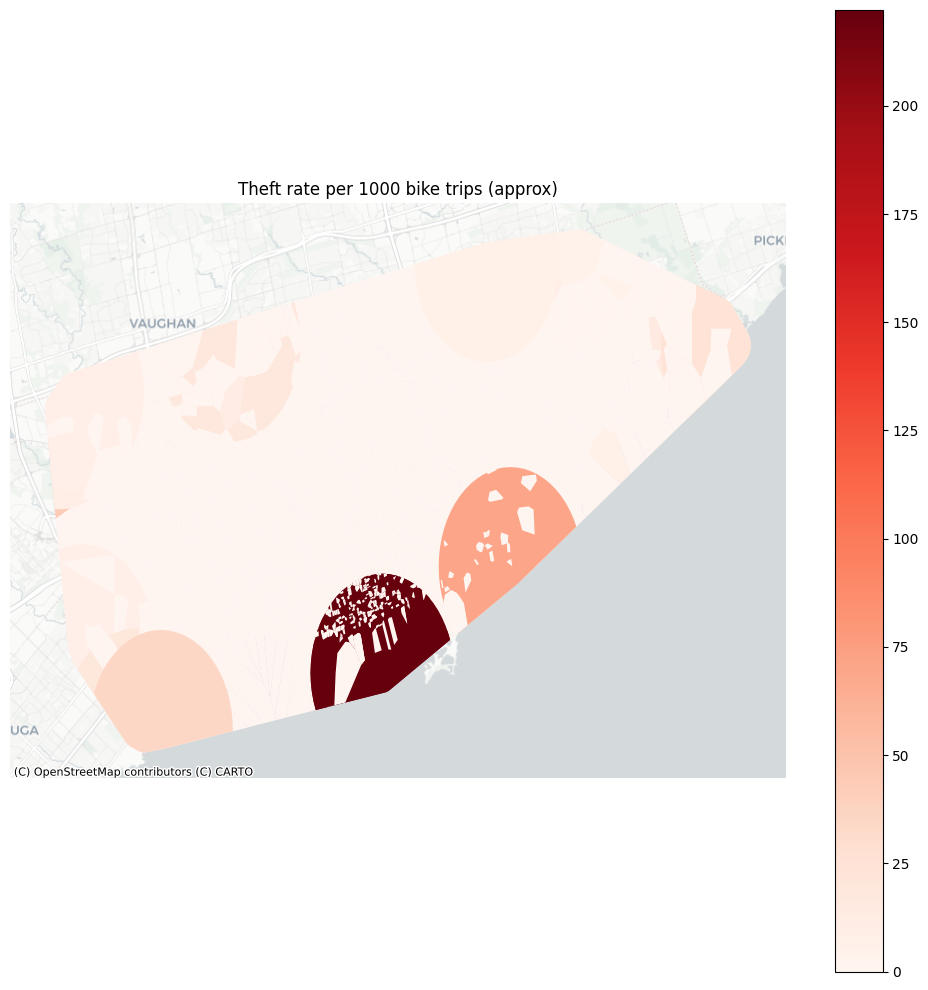

In [28]:
# Diagnostics: print CRS, bounds and non-zero counts to help explain why the map may be off
print("vor_rates: rows=", len(vor_rates))
print("vor_rates CRS:", vor_rates.crs)
print("thefts (th_gdf) CRS:", th_gdf.crs, "bounds:", th_gdf.total_bounds if len(th_gdf)>0 else None)
print("tts CRS:", (tts.crs if isinstance(tts, gpd.GeoDataFrame) and len(tts)>0 else None),
      "bounds:", (tts.total_bounds if isinstance(tts, gpd.GeoDataFrame) and len(tts)>0 else None))
print("vor bounds:", vor_rates.total_bounds)
print("polygons with theft_count>0:", (vor_rates['theft_count']>0).sum())
print("polygons with bike_trips>0:", (vor_rates['bike_trips']>0).sum())
print("bike_trips total:", vor_rates['bike_trips'].sum(), "theft_count total:", vor_rates['theft_count'].sum())
print("Top 10 rates (non-NA):")
print(vor_rates[['theft_count','bike_trips','theft_per_1000_trips']].sort_values('theft_per_1000_trips', ascending=False).head(10))

# show centroid of the top polygon (for quick location check)
if len(vor_rates) > 0:
    top_idx = vor_rates['theft_per_1000_trips'].fillna(-1).idxmax()
    if pd.notna(top_idx):
        c = vor_rates.loc[top_idx, 'geometry'].centroid
        print("Top polygon centroid (lon,lat):", c.x, c.y)

# Plot (unchanged) using a plot column that fills NA for visualization
plot_col = vor_rates['theft_per_1000_trips'].fillna(0)
plot_gdf = vor_rates.copy()
plot_gdf['plot_rate'] = plot_col
ax = plot_gdf.to_crs(epsg=3857).plot(column="plot_rate", cmap="Reds", legend=True, figsize=(10,10))
# add basemap with fallbacks (CartoDB preferred, then OpenStreetMap); if none available, continue without basemap
provider = None
try:
    provider = ctx.providers.CartoDB.Positron
except Exception:
    try:
        provider = ctx.providers.OpenStreetMap.Mapnik
    except Exception:
        provider = None

if provider is not None:
    try:
        ctx.add_basemap(ax, source=provider)
    except Exception as e:
        print("Warning: could not add basemap:", e)

plt.title("Theft rate per 1000 bike trips (approx)")
plt.axis('off')
plt.tight_layout()

## Notes and next steps

- For production: extract the functions into a module (we will create `src/bikespace_data/bicycle_theft/voronoi_tool.py`) and add unit tests.
- Consider power diagrams/weighted Voronoi or KDE smoothing for small counts.
- For large point sets, consider aggregating by grid or sampling before Voronoi.
- Add CLI and GitHub Actions to test and run periodically.


In [6]:
# Generalized loader for TTS trips that handles GeoJSON (preferred) or CSV

def load_tts_trips(source: str | Path, mode_col: str = "MODE") -> gpd.GeoDataFrame:
    """Load TTS trip data from a GeoJSON (preferred) or CSV.

    If a GeoJSON (or any vector format) is provided, read with GeoPandas and filter bike modes if possible.
    Otherwise, read CSV and attempt to infer origin coordinates and build a GeoDataFrame.
    """
    try:
        # try geopandas first (works with file paths or raw GitHub URLs to GeoJSON)
        gdf = gpd.read_file(source)
        if mode_col in gdf.columns:
            gdf = gdf[gdf[mode_col].astype(str).str.lower().isin(["bike", "bicycle"])].copy()
        gdf = gdf.to_crs(epsg=4326)
        print(f"Loaded {len(gdf)} bike trip points from GeoJSON/vector source")
        return gdf
    except Exception:
        # fallback to CSV behavior
        df = pd.read_csv(source)
        if mode_col in df.columns:
            bike_df = df[df[mode_col].astype(str).str.lower().isin(["bike", "bicycle"])].copy()
        else:
            bike_df = df
        possible_x = [c for c in bike_df.columns if "ORIGIN_X" in c.upper() or c.upper() in ("X","LON","LONGITUDE","LONG")]
        possible_y = [c for c in bike_df.columns if "ORIGIN_Y" in c.upper() or c.upper() in ("Y","LAT","LATITUDE")]
        if possible_x and possible_y:
            xcol = possible_x[0]
            ycol = possible_y[0]
            bike_df[xcol] = pd.to_numeric(bike_df[xcol], errors="coerce")
            bike_df[ycol] = pd.to_numeric(bike_df[ycol], errors="coerce")
            bike_df = bike_df.dropna(subset=[xcol,ycol])
            gdf = gpd.GeoDataFrame(bike_df, geometry=gpd.points_from_xy(bike_df[xcol], bike_df[ycol]), crs="EPSG:4326")
            print(f"Loaded {len(gdf)} bike trip points from CSV source")
            return gdf
        else:
            print("No coordinate columns detected in CSV; returning empty GeoDataFrame")
            return gpd.GeoDataFrame(bike_df)


In [7]:
# Use the zone GeoJSON from the School of Cities repo as the initial TTS source
TTS_TRIPS_SOURCE = "https://raw.githubusercontent.com/schoolofcities/transportation-tomorrow-survey/main/data/tts2022zones_data.geojson"

# Load using the generalized loader
try:
    tts = load_tts_trips(TTS_TRIPS_SOURCE)
except Exception as e:
    print(f"Could not load TTS source: {e}")
    tts = gpd.GeoDataFrame()

Loaded 5790 bike trip points from GeoJSON/vector source


In [40]:
# Search School of Cities repo for trip-level files and load bike trips (exact counts)
import requests
print('Searching School of Cities repo for trip-level files...')
repo_api = 'https://api.github.com/repos/schoolofcities/transportation-tomorrow-survey/git/trees/main?recursive=1'
resp = requests.get(repo_api)
resp.raise_for_status()
files = [f['path'] for f in resp.json().get('tree', [])]
cands = [p for p in files if ('trip' in p.lower() or 'trips' in p.lower()) and p.lower().endswith(('.csv', '.geojson', '.json'))]
print('Candidates:', cands[:20])

trip_points_gdf = gpd.GeoDataFrame(columns=['geometry'], crs='EPSG:4326')
if not cands:
    print('No trip-level files found in repo. Consider running repo preprocessing to produce trip points.')
else:
    # prefer CSV candidates
    csvs = [p for p in cands if p.lower().endswith('.csv')]
    chosen = csvs[0] if csvs else cands[0]
    raw_url = f'https://raw.githubusercontent.com/schoolofcities/transportation-tomorrow-survey/main/{chosen}'
    print('Using', chosen)
    # stream read in chunks and filter bike-mode trips
    chunk_iter = pd.read_csv(raw_url, chunksize=100_000)
    rows = []
    xcol = ycol = None
    mode_col = None
    total_bike = 0
    for chunk in chunk_iter:
        if mode_col is None:
            cand_modes = [c for c in chunk.columns if 'mode' in c.lower()]
            mode_col = cand_modes[0] if cand_modes else None
        if xcol is None or ycol is None:
            possible_x = [c for c in chunk.columns if 'origin_x' in c.lower() or 'x'==c.lower() or 'lon' in c.lower() or 'long' in c.lower()]
            possible_y = [c for c in chunk.columns if 'origin_y' in c.lower() or 'y'==c.lower() or 'lat' in c.lower()]
            if possible_x and possible_y:
                xcol = possible_x[0]
                ycol = possible_y[0]
        if mode_col:
            bike_mask = chunk[mode_col].astype(str).str.lower().isin(['bike','bicycle','bicycle ride','cycle']).fillna(False)
        else:
            bike_mask = pd.Series(True, index=chunk.index)  # keep all if no mode col
        if xcol and ycol:
            chunk[xcol] = pd.to_numeric(chunk[xcol], errors='coerce')
            chunk[ycol] = pd.to_numeric(chunk[ycol], errors='coerce')
            chunk = chunk.dropna(subset=[xcol,ycol])
            bikes = chunk.loc[bike_mask, [xcol,ycol]].copy()
            total_bike += len(bikes)
            rows.append(bikes)
        else:
            # cannot form points; stop
            print('Trip CSV has no obvious coordinate columns; skipping')
            break
    if rows:
        all_bikes = pd.concat(rows, ignore_index=True)
        trip_points_gdf = gpd.GeoDataFrame(all_bikes, geometry=gpd.points_from_xy(all_bikes.iloc[:,0], all_bikes.iloc[:,1]), crs='EPSG:4326')
        print('Loaded', len(trip_points_gdf), 'bike trip points (exact)')

# If trip_points_gdf has points, spatially join to vor_disjoint and compute exact bike trips per polygon
if len(trip_points_gdf) > 0:
    join_pts = gpd.sjoin(trip_points_gdf, vor_disjoint, predicate='within', how='left')
    exact_usage = join_pts.groupby('vor_id').size().rename('bike_trips_exact')
    print('Exact bike trip count sum (joined):', exact_usage.sum())
    # merge into result2 (bike-estimated result) to compare and update
    result_exact = vor_disjoint.merge(thft, left_on='vor_id', right_index=True, how='left')
    result_exact = result_exact.merge(exact_usage, left_on='vor_id', right_index=True, how='left')
    result_exact['theft_count'] = result_exact['theft_count'].fillna(0).astype(int)
    result_exact['bike_trips'] = result_exact['bike_trips_exact'].fillna(0)
    result_exact['theft_per_1000_trips'] = (result_exact['theft_count'] / result_exact['bike_trips'].replace({0: pd.NA})) * 1000
    vor_rates_disjoint_exact = result_exact
    print('Final totals (exact): theft_count sum:', result_exact['theft_count'].sum(), 'bike_trips sum:', result_exact['bike_trips'].sum())

Searching School of Cities repo for trip-level files...
Candidates: ['src/routes/line-2-trips/assets/line2-station-flows.csv']
Using src/routes/line-2-trips/assets/line2-station-flows.csv
Trip CSV has no obvious coordinate columns; skipping


In [38]:
# Diagnostics: inspect TTS zone attributes for bike-specific weights
print("TTS columns:", tts.columns.tolist())
# look for bike-related columns
bike_cols = [c for c in tts.columns if 'bike' in c.lower() or 'bicycle' in c.lower() or 'mode' in c.lower()]
print('Potential bike-related columns:', bike_cols)
# inspect candidate weight columns
candidates = [c for c in ('TTS2022','TTS','trips','bike_trips','BIKE_TRIPS','bike') if c in tts.columns]
for c in candidates:
    print(c, 'dtype:', tts[c].dtype, 'min:', tts[c].min(), 'max:', tts[c].max())
# show a few sample rows
print('\nSample TTS zone attributes (first 5 rows):')
print(tts.head()[candidates + bike_cols].fillna(''))

# Quick estimate: compute bike_trips_est = TTS2022 * mode_bike (support percent or proportion)
if 'TTS2022' in tts.columns and 'mode_bike' in tts.columns:
    mb = pd.to_numeric(tts['mode_bike'], errors='coerce').fillna(0)
    if mb.max() > 1.5:
        # likely given as percent (e.g., 3.0 -> 3%)
        prop = mb / 100.0
        scale = 'percent'
    else:
        prop = mb
        scale = 'proportion'
    tts['bike_trips_est'] = tts['TTS2022'] * prop
    print(f"Computed bike_trips_est using mode_bike (scale={scale}). Sum bike_trips_est: {tts['bike_trips_est'].sum():,.0f}")
else:
    print("Cannot compute bike_trips_est: missing TTS2022 or mode_bike columns")

# Recompute usage aggregation using estimated bike trips (if available)
if 'bike_trips_est' in tts.columns:
    u_join = gpd.sjoin(tts[['bike_trips_est','geometry']], vor_disjoint, predicate='intersects', how='left')
    usage_est = u_join.groupby('vor_id')['bike_trips_est'].sum().rename('bike_trips')
    # merge into final result
    result2 = vor_disjoint.merge(thft, left_on='vor_id', right_index=True, how='left')
    result2 = result2.merge(usage_est, left_on='vor_id', right_index=True, how='left')
    result2['theft_count'] = result2['theft_count'].fillna(0).astype(int)
    result2['bike_trips'] = result2['bike_trips'].fillna(0)
    result2['theft_per_1000_trips'] = (result2['theft_count'] / result2['bike_trips'].replace({0: pd.NA})) * 1000
    print('Estimated bike_trips total (sum):', result2['bike_trips'].sum())
    vor_rates_disjoint_bikeest = result2
else:
    print('No bike_trips_est found; skipping bike-based aggregation')

TTS columns: ['TTS2022', 'population', 'hhlds', 'hhld_sample', 'population_density', 'low_income_hhlds_percent', 'immig_recent', 'veh_per_hhld', 'hhlds_no_veh', 'drivers_lic_perperson_20to75', 'transpass_perperson_6up', 'trip_km_avg', 'trips_5up_per_person', 'activities_mean', 'mode_bike', 'mode_walk', 'mode_transit', 'mode_drive', 'trips_less5km_percent', 'trips_less5km_percent_car', 'children_driven_to_school', 'geometry']
Potential bike-related columns: ['mode_bike', 'mode_walk', 'mode_transit', 'mode_drive']
TTS2022 dtype: int32 min: 1001 max: 27069

Sample TTS zone attributes (first 5 rows):
   TTS2022 mode_bike  mode_walk mode_transit mode_drive
0     1001  0.759519  24.934502    10.888914  62.871931
1     1002                                             
2     1003                                             
3     1004  3.001154  50.383157     9.971559  34.961927
4     1005                                             
Computed bike_trips_est using mode_bike (scale=percent). Sum

In [9]:
# Fetch the latest bicycle-thefts dataset using the project updater
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "src"))

from bikespace_data.bicycle_theft.update_bicycle_theft import update_bicycle_thefts

# Run the updater to create the normalized thefts GeoJSON used by this notebook
update_bicycle_thefts(archive=False)

Checking open.toronto.ca for bicycle-thefts dataset


TypeError: fromisoformat: argument must be str

In [10]:
# Directly fetch the theft GeoDataFrame and write the normalized GeoJSON (bypassing metadata validation)
from bikespace_data.bicycle_theft.update_bicycle_theft import _pick_resource_id
from bikespace_data.resources.toronto_open_data import request_tod_gdf

rid = _pick_resource_id("bicycle-thefts")
resp = request_tod_gdf(dataset_name="bicycle-thefts", resource_id=rid)
th_gdf = resp["gdf"]
# ensure 4326
th_gdf = th_gdf.to_crs(epsg=4326)

(out := Path("bicycle_theft") / "output_files").mkdir(parents=True, exist_ok=True)
th_gdf.to_file(out / "bicycle-thefts-normalized.geojson", driver="GeoJSON")
print(f"Saved {len(th_gdf)} thefts to {out / 'bicycle-thefts-normalized.geojson'}")

DataSourceError: '/vsimem/pyogrio_b65c1e588d8d4de6b4922c9bb824bf31' not recognized as being in a supported file format.; It might help to specify the correct driver explicitly by prefixing the file path with '<DRIVER>:', e.g. 'CSV:path'.

In [26]:
# Clean thefts and (re)load TTS zones

def clean_thefts_gdf(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Clean thefts GeoDataFrame:
    - ensure EPSG:4326
    - drop empty geometries
    - convert non-Point geometries to centroids
    - detect and fix probable swapped x/y coordinates
    - remove points outside a broad North America bbox (noise/ocean points)
    """
    g = gdf.copy()
    if g.crs is None:
        g.set_crs(epsg=4326, inplace=True)
    else:
        g = g.to_crs(epsg=4326)

    g = g[~g.geometry.is_empty & g.geometry.notna()].copy()

    # convert non-points to centroids
    non_pts = ~g.geometry.geom_type.eq("Point")
    if non_pts.any():
        print(f"Converting {non_pts.sum()} non-point geometries to centroids")
        g.loc[non_pts, "geometry"] = g.loc[non_pts, "geometry"].centroid

    # x/y checks
    g["x"] = g.geometry.x
    g["y"] = g.geometry.y

    # heuristic: suspicious records where latitude is near 0, or where lon>0 and lat>0 (likely swapped),
    # or where latitude is far outside plausible range (< -20)
    swap_mask = ((g["y"].abs() < 0.5) | ((g["x"] > 0) & (g["y"] > 0)) | (g["y"] < -20))
    if swap_mask.any():
        print(f"Detected {swap_mask.sum()} records with suspicious coords; swapping x/y for them")
        g.loc[swap_mask, ["x", "y"]] = g.loc[swap_mask, ["y", "x"]].values
        g["geometry"] = g.apply(lambda r: Point(r["x"], r["y"]), axis=1)

    # keep only broad North America extents to remove stray ocean points
    na_mask = (g["x"] >= -130) & (g["x"] <= -50) & (g["y"] >= 5) & (g["y"] <= 70)
    removed = (~na_mask).sum()
    if removed > 0:
        print(f"Removing {removed} points outside broad North America bbox")
        g = g.loc[na_mask].copy()

    g = g.drop(columns=["x", "y"]).reset_index(drop=True)
    print(f"After cleaning: {len(g)} theft points")
    return g

# apply cleaning to the thefts we just downloaded
th_gdf = clean_thefts_gdf(th_gdf)

# Reload TTS zones (GeoJSON) with a robust attempt and detect a weight column
try:
    tts = gpd.read_file(TTS_TRIPS_SOURCE)
    print(f"Reloaded TTS zones: {len(tts)} features, CRS={tts.crs}")
except Exception as e:
    print("Could not reload TTS zones:", e)
    tts = gpd.GeoDataFrame()

# try to guess a weight column in zones
tts_weight_col = None
if len(tts) > 0:
    for c in ("TTS2022", "TTS", "trips", "bike_trips", "TRIPS"):
        if c in tts.columns and pd.api.types.is_numeric_dtype(tts[c]):
            tts_weight_col = c
            print("Using TTS weight column:", c)
            break
    if tts_weight_col is None:
        print("No obvious numeric weight column found in TTS zones; aggregation will count intersecting zones")

Converting 39473 non-point geometries to centroids
Detected 341 records with suspicious coords; swapping x/y for them


/tmp/ipykernel_246996/2556557054.py:23: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  g.loc[non_pts, "geometry"] = g.loc[non_pts, "geometry"].centroid


Removing 341 points outside broad North America bbox
After cleaning: 39132 theft points
Reloaded TTS zones: 5790 features, CRS=EPSG:4326
Using TTS weight column: TTS2022


In [81]:
# Rebuild Voronoi and aggregated rates after cleaning
# Create points (centroids), sample if too many, build Voronoi and aggregate
# Compute centroids in a projected CRS to avoid centroid-in-geographic-CRS warnings
pts_proj = th_gdf.to_crs(epsg=3857).copy()
pts_proj["geometry"] = pts_proj.geometry.centroid
pts = pts_proj.to_crs(epsg=4326).reset_index(drop=True)

MAX_POINTS = 3000
if len(pts) > MAX_POINTS:
    print(f"Large point set ({len(pts)}), sampling {MAX_POINTS} for Voronoi")
    pts = pts.sample(MAX_POINTS, random_state=1).reset_index(drop=True)

# Determine a sensible clipping polygon to avoid Voronoi spilling over ocean or outside city
clip_polygon = None
# Prefer an explicit city boundary if provided
if CITY_BOUNDARY_PATH is not None and Path(CITY_BOUNDARY_PATH).exists():
    try:
        city = gpd.read_file(CITY_BOUNDARY_PATH)
        city = city.to_crs(epsg=4326)
        clip_polygon = city.unary_union
        print('Using CITY_BOUNDARY_PATH for clipping Voronoi')
    except Exception as e:
        print('Failed to read CITY_BOUNDARY_PATH:', e)

# Try OSM-backed city boundary via osmnx (best quality) or Nominatim fallback
if clip_polygon is None:
    try:
        import osmnx as ox
        print('Attempting to fetch city boundary via osmnx...')
        # geocode_to_gdf returns boundary polygon for well-known place names
        city_gdf = ox.geocode_to_gdf('City of Toronto, Ontario, Canada')
        if len(city_gdf) > 0:
            city_gdf = city_gdf.to_crs(epsg=4326)
            clip_polygon = city_gdf.unary_union
            print('Using OSM city boundary via osmnx for clipping Voronoi')
    except Exception as e:
        print('osmnx not available or failed:', e)

# Try Overpass API to fetch a more authoritative OSM admin boundary first
if clip_polygon is None:
    try:
        import requests
        print('Attempting to fetch OSM admin boundary via Overpass API...')
        overpass = 'https://overpass-api.de/api/interpreter'
        q = '''
        [out:json][timeout:25];
        relation
          ["boundary"="administrative"]
          ["name"="Toronto"]
          ["admin_level"~"6|8"];
        out geom;
        '''
        resp = requests.post(overpass, data={'data': q}, headers={'User-Agent': 'parking-map-data/1.0'})
        resp.raise_for_status()
        data = resp.json()
        geom = None
        for el in data.get('elements', []):
            # take the first element with geometry and try to build a polygon
            if el.get('geometry'):
                coords = [(pt['lon'], pt['lat']) for pt in el['geometry']]
                try:
                    poly = Polygon(coords)
                    if poly.is_valid and poly.area > 0:
                        geom = poly
                        break
                except Exception:
                    continue
        if geom is not None:
            clip_polygon = geom
            print('Using Overpass admin boundary for Toronto')
    except Exception as e:
        print('Overpass fetch failed:', e)

# If Overpass didn't work, fall back to Nominatim polygon
if clip_polygon is None:
    try:
        import requests
        print('Attempting to fetch city polygon via Nominatim (fallback)')
        nom = requests.get('https://nominatim.openstreetmap.org/search', params={'q':'City of Toronto, Ontario, Canada','format':'geojson','polygon_geojson':1,'limit':1}, headers={'User-Agent':'parking-map-data/1.0'})
        nom.raise_for_status()
        data = nom.json()
        if data.get('features'):
            from shapely.geometry import shape
            clip_polygon = shape(data['features'][0]['geometry'])
            print('Using Nominatim polygon for Toronto')
    except Exception as e:
        print('Nominatim fallback failed:', e)

# Fallback: use union of TTS zones (should follow municipal land area); clean invalid geometries first
if clip_polygon is None and isinstance(tts, gpd.GeoDataFrame) and len(tts) > 0:
    try:
        tts_clean = tts.copy()
        tts_clean = tts_clean[~tts_clean.geometry.is_empty & tts_clean.geometry.notna()]
        tts_clean['geometry'] = tts_clean.geometry.buffer(0)
        tts_clean = tts_clean[tts_clean.geometry.notna()]
        clip_polygon = tts_clean.unary_union
        print('Using cleaned TTS zone union for clipping Voronoi')
    except Exception as e:
        print('TTS union failed; attempting robust union fallback:', e)
        try:
            from shapely.ops import unary_union as shapely_unary_union
            geoms = [g.buffer(0) for g in tts.geometry if g is not None and not g.is_empty]
            clip_polygon = shapely_unary_union(geoms)
            print('Using shapely unary_union of TTS zones for clipping Voronoi')
        except Exception as ee:
            print('Fallback union also failed:', ee)
            clip_polygon = None

# Last resort: convex hull of points with a small buffer (lower buffer to avoid overreach)
if clip_polygon is None:
    clip_polygon = MultiPoint(list(pts.geometry)).convex_hull.buffer(0.005)
    print('Using convex hull (small buffer) of theft points for clipping Voronoi')

# ensure valid polygon (repair small topology issues)
try:
    clip_polygon = clip_polygon.buffer(0)
except Exception:
    pass

print('Building Voronoi (SciPy fallback if necessary)')
try:
    if SCIPY_AVAILABLE:
        vor = build_voronoi_scipy(pts, clip_polygon=clip_polygon)
    else:
        vor = build_voronoi_shapely(pts, clip_polygon=clip_polygon)
except Exception as e:
    print('Voronoi build failed:', e)
    vor = gpd.GeoDataFrame(geometry=[], crs='EPSG:4326')

# Ensure polygons are clipped to clip_polygon (safety) and drop empty geometries
try:
    vor = gpd.GeoDataFrame(geometry=[g.intersection(clip_polygon) for g in vor.geometry], crs='EPSG:4326')
    vor = vor.loc[~vor.geometry.is_empty & vor.geometry.notna()].reset_index(drop=True)
except Exception as e:
    print('Warning: post-clipping failed:', e)

print('Voronoi polygons (clipped):', len(vor))

# aggregate (use weight col if present)
vor_rates = aggregate_to_voronoi(vor, th_gdf, tts, tts_weight_col if 'tts_weight_col' in globals() else None)
print('Aggregated vor_rates: rows=', len(vor_rates))

Large point set (39132), sampling 3000 for Voronoi
osmnx not available or failed: No module named 'osmnx'
Attempting to fetch OSM admin boundary via Overpass API...
Overpass fetch failed: 504 Server Error: Gateway Timeout for url: https://overpass-api.de/api/interpreter
Attempting to fetch city polygon via Nominatim (fallback)
Using Nominatim polygon for Toronto
Building Voronoi (SciPy fallback if necessary)
Voronoi polygons (clipped): 3000
Aggregated vor_rates: rows= 3000


In [82]:
# Create a disjoint partition from the Voronoi polygons and re-aggregate
from shapely.ops import unary_union, polygonize

print("Creating disjoint partition from Voronoi polygons")
merged = unary_union(vor.boundary)
parts = list(polygonize(merged))
parts_gdf = gpd.GeoDataFrame(geometry=parts, crs=vor.crs)
print("Partition pieces:", len(parts_gdf))

# ensure vor has vor_id
if 'vor_id' not in vor.columns:
    vor = vor.reset_index(drop=True).copy()
    vor['vor_id'] = range(len(vor))
# assign parts to vor_id by largest intersection area (use projected CRS for accurate areas)
vor_proj = vor.to_crs(epsg=3857)
parts_proj = parts_gdf.to_crs(epsg=3857)
# clean geometry validity before spatial ops
vor_proj['geometry'] = vor_proj.geometry.buffer(0)
parts_proj['geometry'] = parts_proj.geometry.buffer(0)
parts_gdf["vor_id"] = -1
for i, part in parts_proj.geometry.items():
    # ensure part is valid
    try:
        part_clean = part.buffer(0)
    except Exception:
        part_clean = part
    candidates = vor_proj[vor_proj.intersects(part_clean)]
    if len(candidates) == 0:
        continue
    # make candidate geometries valid
    candidates = candidates.copy()
    candidates['geometry'] = candidates.geometry.buffer(0)
    # compute intersection areas with error handling
    try:
        inter_areas = candidates.geometry.intersection(part_clean).area
    except Exception:
        # fallback: compute intersection using pairwise safe intersections
        inter_areas = []
        for idx2, geom2 in candidates.geometry.items():
            try:
                inter_areas.append(geom2.intersection(part_clean).area)
            except Exception:
                inter_areas.append(0.0)
        inter_areas = pd.Series(inter_areas, index=candidates.index)
    max_idx = inter_areas.idxmax()
    parts_gdf.at[i, "vor_id"] = int(vor_proj.loc[max_idx, "vor_id"])

# remove parts not assigned
parts_gdf = parts_gdf[parts_gdf["vor_id"] != -1].copy()
print("Assigned parts:", len(parts_gdf))

# dissolve parts back to one polygon per vor_id (disjoint)
vor_disjoint = parts_gdf.dissolve(by="vor_id").reset_index()
vor_disjoint = vor_disjoint.rename(columns={"vor_id": "vor_id"})
# keep only vor_id and geometry
vor_disjoint = vor_disjoint[["vor_id", "geometry"]]
print("Disjoint vor polygons:", len(vor_disjoint))

# Re-aggregate using the disjoint polygons
vor_rates_disjoint = aggregate_to_voronoi(vor_disjoint, th_gdf, tts, tts_weight_col if 'tts_weight_col' in globals() else None)
print("Re-aggregated theft_count sum:", vor_rates_disjoint['theft_count'].sum(), "source thefts:", len(th_gdf))
print("Re-aggregated bike_trips sum:", vor_rates_disjoint['bike_trips'].sum())
print("Polygons with bike_trips>0:", (vor_rates_disjoint['bike_trips']>0).sum())

Creating disjoint partition from Voronoi polygons
Partition pieces: 2108
Assigned parts: 2108
Disjoint vor polygons: 1601
Re-aggregated theft_count sum: 39111 source thefts: 39132
Re-aggregated bike_trips sum: 29147.0
Polygons with bike_trips>0: 8


In [83]:
# Morphological sliver removal: merge small partition pieces into neighboring polygons by shared boundary length
# Parameter: minimum area in square meters below which a polygon is considered a sliver
MIN_AREA_M2 = 1000  # adjust as needed (default 1,000 m^2)

print(f"Removing sliver polygons smaller than {MIN_AREA_M2} m^2 (merge to largest-touching neighbor)")
# operate in projected CRS for accurate area and distance
parts_proj = parts_gdf.to_crs(epsg=3857).copy()
parts_proj['area_m2'] = parts_proj.geometry.area
small_mask = parts_proj['area_m2'] < MIN_AREA_M2
n_small = int(small_mask.sum())
print('Partition pieces:', len(parts_gdf), 'small pieces:', n_small)

if n_small > 0:
    large = parts_proj[~small_mask].copy()
    small = parts_proj[small_mask].copy()

    # build an index of large polygons for nearest fallback
    large_sindex = large.sindex

    assign_map = {}
    for idx, row in small.iterrows():
        geom = row.geometry
        # find touching candidates among large polygons (use iloc for positional indices)
        cand_pos = list(large_sindex.intersection(geom.bounds))
        if len(cand_pos) > 0:
            try:
                candidates = large.iloc[cand_pos].copy()
            except Exception:
                candidates = large.copy()
        else:
            candidates = large.iloc[[]].copy()

        # make candidate geometries valid
        candidates['geometry'] = candidates.geometry.buffer(0)
        # ensure part is valid
        try:
            part_clean = geom.buffer(0)
        except Exception:
            part_clean = geom

        # keep only those that actually intersect/touch
        candidates = candidates[candidates.intersects(part_clean)]
        if len(candidates) == 0:
            # fallback: assign to nearest large polygon by centroid distance
            dists = large.geometry.distance(part_clean.centroid)
            nearest_idx = dists.idxmin()
            assign = int(large.loc[nearest_idx, 'vor_id'])
        else:
            # compute shared boundary length (intersection length) and pick max
            try:
                shared_lengths = candidates.geometry.intersection(part_clean).length
                if shared_lengths.sum() == 0:
                    # fallback to intersection area if boundary length is zero
                    shared_areas = candidates.geometry.intersection(part_clean).area
                    max_idx = shared_areas.idxmax()
                    assign = int(candidates.loc[max_idx, 'vor_id'])
                else:
                    max_idx = shared_lengths.idxmax()
                    assign = int(candidates.loc[max_idx, 'vor_id'])
            except Exception:
                # fallback to nearest within candidates
                dists = candidates.geometry.distance(part_clean.centroid)
                nearest_idx = dists.idxmin()
                assign = int(candidates.loc[nearest_idx, 'vor_id'])
        assign_map[int(row['vor_id'])] = assign

    # apply assignments to parts and dissolve back into cleaned vor polygons
    parts_proj = parts_proj.copy()
    parts_proj['vor_id'] = parts_proj['vor_id'].apply(lambda v: assign_map[v] if int(v) in assign_map else int(v))

    # robust dissolve using shapely.unary_union per group to avoid topology errors
    from shapely.ops import unary_union as shapely_unary_union
    groups = []
    for vid, grp in parts_proj.groupby('vor_id'):
        geoms = [g.buffer(0) for g in grp.geometry if g is not None and not g.is_empty]
        try:
            merged = shapely_unary_union(geoms)
        except Exception:
            # fallback: iterative unary_union pairwise
            merged = grp.geometry.unary_union
        groups.append({'vor_id': int(vid), 'geometry': merged})
    vor_clean_proj = gpd.GeoDataFrame(groups, crs=parts_proj.crs)
    vor_clean = vor_clean_proj[['vor_id','geometry']].to_crs(epsg=4326)
    print('After merging slivers: cleaned polygons:', len(vor_clean))
else:
    vor_clean = vor_disjoint.copy()
    print('No slivers to merge; using original disjoint polygons')

# Re-aggregate using the cleaned/disjoint polygons
vor_rates_clean = aggregate_to_voronoi(vor_clean, th_gdf, tts, tts_weight_col if 'tts_weight_col' in globals() else None)
print('Re-aggregated theft_count sum (clean):', vor_rates_clean['theft_count'].sum(), 'source thefts:', len(th_gdf))

# If bike_trips_est exists in tts, recompute bike-estimated aggregation for cleaned polygons as well
if isinstance(tts, gpd.GeoDataFrame) and 'bike_trips_est' in tts.columns:
    u_join = gpd.sjoin(tts[['bike_trips_est','geometry']], vor_clean, predicate='intersects', how='left')
    usage_est = u_join.groupby('vor_id')['bike_trips_est'].sum().rename('bike_trips')
    vor_rates_clean_bikeest = vor_clean.merge(thft, left_on='vor_id', right_index=True, how='left')
    vor_rates_clean_bikeest = vor_rates_clean_bikeest.merge(usage_est, left_on='vor_id', right_index=True, how='left')
    vor_rates_clean_bikeest['theft_count'] = vor_rates_clean_bikeest['theft_count'].fillna(0).astype(int)
    vor_rates_clean_bikeest['bike_trips'] = vor_rates_clean_bikeest['bike_trips'].fillna(0)
    vor_rates_clean_bikeest['theft_per_1000_trips'] = (vor_rates_clean_bikeest['theft_count'] / vor_rates_clean_bikeest['bike_trips'].replace({0: pd.NA})) * 1000
    print('Computed bike-estimated aggregation for cleaned polygons')

Removing sliver polygons smaller than 1000 m^2 (merge to largest-touching neighbor)
Partition pieces: 2108 small pieces: 20
After merging slivers: cleaned polygons: 1592
Re-aggregated theft_count sum (clean): 39111 source thefts: 39132
Computed bike-estimated aggregation for cleaned polygons


In [84]:
# Final clipping: apply a small inward buffer (meters) to the mask and drop/tidy tiny fragments
BUFFER_NEG_M = 3  # meters (try small inward buffer to shave coastal spikes)
MIN_FRAGMENT_AREA_M2 = 2000  # fragments smaller than this will be reassigned/merged

print(f"Applying inward buffer of {BUFFER_NEG_M} m and dropping fragments < {MIN_FRAGMENT_AREA_M2} m^2")

# build the mask (project to metric CRS for buffering)
mask_gdf = gpd.GeoDataFrame(geometry=[clip_polygon], crs='EPSG:4326')
mask_proj = mask_gdf.to_crs(epsg=3857)
try:
    mask_shrunk = mask_proj.geometry.buffer(-BUFFER_NEG_M).unary_union
    if mask_shrunk.is_empty:
        print('Inward buffer produced empty geometry; using original mask (no shrink)')
        mask_shrunk = mask_proj.unary_union
except Exception as e:
    print('Buffering mask failed, using original mask:', e)
    mask_shrunk = mask_proj.unary_union

# intersect cleaned vor polygons with the shrunken mask
vor_clean_proj = vor_clean.to_crs(epsg=3857).copy()
vor_clean_proj['geometry'] = vor_clean_proj.geometry.intersection(mask_shrunk)
vor_clean_proj = vor_clean_proj.loc[~vor_clean_proj.geometry.is_empty & vor_clean_proj.geometry.notna()].reset_index(drop=True)

n_before = len(vor_clean)
n_after = len(vor_clean_proj)
print('Polygons before clipping:', n_before, 'after clipping:', n_after)

# drop small fragments and merge them into nearest large polygon
vor_clean_proj['area_m2'] = vor_clean_proj.geometry.area
small_frags = vor_clean_proj[vor_clean_proj['area_m2'] < MIN_FRAGMENT_AREA_M2].copy()
large_pieces = vor_clean_proj[vor_clean_proj['area_m2'] >= MIN_FRAGMENT_AREA_M2].copy()
print('Small fragments:', len(small_frags), 'Large pieces:', len(large_pieces))

from shapely.ops import unary_union as shapely_unary_union

if len(small_frags) > 0 and len(large_pieces) > 0:
    # assign each small fragment to nearest large piece (centroid distance)
    small_pts = gpd.GeoDataFrame(geometry=small_frags.geometry.centroid, crs=vor_clean_proj.crs)
    large_index = large_pieces[['vor_id','geometry']].copy()
    nearest = gpd.sjoin_nearest(small_pts, large_index, how='left', distance_col='dist')
    vor_col = next((c for c in nearest.columns if 'vor_id' in c), None)
    if vor_col is None:
        raise RuntimeError('sjoin_nearest did not return vor_id column')
    # map small fragment index -> assigned vor_id
    assign_map = dict(zip(small_frags.index, nearest[vor_col].values))
    # prepare combined df with assignments
    small_assigned = small_frags.copy()
    small_assigned['vor_id'] = small_assigned.index.map(lambda i: assign_map.get(i, None))
    small_assigned = small_assigned.dropna(subset=['vor_id']).copy()

    combined = pd.concat([large_pieces[['vor_id','geometry']], small_assigned[['vor_id','geometry']]], ignore_index=True)
    groups = []
    for vid, grp in combined.groupby('vor_id'):
        geoms = [g.buffer(0) for g in grp.geometry if g is not None and not g.is_empty]
        try:
            merged = shapely_unary_union(geoms)
        except Exception:
            merged = grp.geometry.unary_union
        groups.append({'vor_id': int(vid), 'geometry': merged})
    vor_final_proj = gpd.GeoDataFrame(groups, crs=vor_clean_proj.crs)
else:
    # nothing to merge or no large pieces; keep what we have
    vor_final_proj = vor_clean_proj[['vor_id','geometry']].copy()

# convert back to EPSG:4326 for downstream joins
vor_final = vor_final_proj[['vor_id','geometry']].to_crs(epsg=4326).reset_index(drop=True)
print('Final polygons after clipping/merge:', len(vor_final))

# Fix unmatched theft points by nearest final polygon and recompute counts (projected for nearest)
joined_final = gpd.sjoin(th_gdf, vor_final[['vor_id','geometry']], predicate='within', how='left')
missing_final = joined_final[joined_final['vor_id'].isna()].copy()
print('Missing thefts after final clipping (before reassign):', len(missing_final))

if len(missing_final) > 0:
    missing_proj = missing_final.to_crs(epsg=3857)
    vor_final_proj = vor_final.to_crs(epsg=3857)[['vor_id','geometry']].copy()
    # drop helper/conflicting index columns if present to avoid sjoin name collisions
    for col in ['index_right','index_left','level_0']:
        if col in missing_proj.columns:
            missing_proj = missing_proj.drop(columns=[col])
        if col in vor_final_proj.columns:
            vor_final_proj = vor_final_proj.drop(columns=[col])
    nearest2 = gpd.sjoin_nearest(missing_proj, vor_final_proj, how='left', distance_col='dist')
    vor_col2 = next((c for c in nearest2.columns if 'vor_id' in c), None)
    if vor_col2 is None:
        raise RuntimeError('sjoin_nearest did not return vor_id for final polygons')
    # assign nearest vor_id back to joined_final (align by index)
    joined_final.loc[nearest2.index, 'vor_id'] = nearest2[vor_col2].values
    print('Assigned nearest vor_id for missing thefts; sample assignments:')
    print(joined_final.loc[joined_final['vor_id'].notna()].head())

    # Extra fallback: for any still-unassigned thefts, use centroid KDTree nearest-centroid assignment
    still_missing = joined_final[joined_final['vor_id'].isna()].copy()
    if len(still_missing) > 0:
        print('Fallback: assigning remaining', len(still_missing), 'thefts by nearest centroid search')
        vor_centroids = vor_final.to_crs(epsg=3857).geometry.centroid.reset_index(drop=True)
        cent_coords = np.array([[p.x, p.y] for p in vor_centroids])
        try:
            from scipy.spatial import cKDTree
        except Exception:
            from scipy.spatial import KDTree as cKDTree  # fallback name
        tree = cKDTree(cent_coords)
        sm_proj = still_missing.to_crs(epsg=3857)
        pts = np.array([[p.x, p.y] for p in sm_proj.geometry])
        dists, idxs = tree.query(pts, k=1)
        # map KDTree indices back to vor_ids (ensure consistent ordering)
        vor_ids_ordered = vor_final.to_crs(epsg=3857).reset_index(drop=True)['vor_id'].tolist()
        assigned_vids = [int(vor_ids_ordered[i]) for i in idxs]
        joined_final.loc[still_missing.index, 'vor_id'] = assigned_vids
        print('Assigned remaining thefts via KDTree nearest-centroid mapping')

# compute theft counts per vor_id
thft_final = joined_final.groupby('vor_id').size().rename('theft_count')

# compute usage counts from TTS zones using the same intersect method as earlier
if len(tts) > 0:
    if 'tts_weight_col' in globals() and tts_weight_col in tts.columns:
        u_join = gpd.sjoin(tts, vor_final, predicate='intersects', how='left')
        usage_final = u_join.groupby('vor_id')[tts_weight_col].sum().rename('bike_trips')
    else:
        u_join = gpd.sjoin(tts, vor_final, predicate='intersects', how='left')
        usage_final = u_join.groupby('vor_id').size().rename('bike_trips')
else:
    usage_final = pd.Series(dtype=float, name='bike_trips')

# merge counts and compute final rate
vor_rates_final = vor_final.merge(thft_final, left_on='vor_id', right_index=True, how='left')
vor_rates_final = vor_rates_final.merge(usage_final, left_on='vor_id', right_index=True, how='left')
vor_rates_final['theft_count'] = vor_rates_final['theft_count'].fillna(0).astype(int)
vor_rates_final['bike_trips'] = vor_rates_final['bike_trips'].fillna(0)
vor_rates_final['theft_per_1000_trips'] = (vor_rates_final['theft_count'] / vor_rates_final['bike_trips'].replace({0: pd.NA})) * 1000

print('Final totals: theft_count sum:', vor_rates_final['theft_count'].sum(), 'source thefts:', len(th_gdf))

# expose for plotting
vor_final_plot = vor_rates_final.copy()

# Save final clipped outputs
OUT_DIR.mkdir(parents=True, exist_ok=True)
fname = OUT_DIR / f'voronoi_theft_rates_disjoint_bikeest_quantiles_clipped_buf{BUFFER_NEG_M}m.geojson'
vor_final_plot.to_file(fname, driver='GeoJSON')
print('Saved final clipped GeoJSON to', fname)


Applying inward buffer of 3 m and dropping fragments < 2000 m^2


/tmp/ipykernel_246996/252161047.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  mask_shrunk = mask_proj.geometry.buffer(-BUFFER_NEG_M).unary_union


Polygons before clipping: 1592 after clipping: 1592
Small fragments: 2 Large pieces: 1590
Final polygons after clipping/merge: 1590
Missing thefts after final clipping (before reassign): 43
Assigned nearest vor_id for missing thefts; sample assignments:
   _id EVENT_UNIQUE_ID   PRIMARY_OFFENCE   OCC_DATE OCC_YEAR  OCC_MONTH  \
0    1  GO-20141263544               B&E 2013-12-26     2013   December   
1    2  GO-20141263784  PROPERTY - FOUND 2014-01-01     2014    January   
2    3  GO-20141261431       THEFT UNDER 2014-01-01     2014    January   
3    4  GO-20149000090       THEFT UNDER 2014-01-01     2014    January   
4    5  GO-20141267465       THEFT UNDER 2013-09-30     2013  September   

     OCC_DOW OCC_DAY OCC_DOY OCC_HOUR  ... BIKE_TYPE BIKE_SPEED BIKE_COLOUR  \
0   Thursday      26     360       19  ...        RC         21      SILRED   
1  Wednesday       1       1       18  ...        RG          1         BLK   
2  Wednesday       1       1        7  ...        MT      

Masking 0 polygons with bike_trips < 10
Saved final plot to /run/media/kchanglani/2TB M.2 Volume/Documents/CodeRepos/parking-map-data/notebooks/notebooks/output/voronoi_theft/voronoi_theft_rates_disjoint_bikeest_quantiles_clipped_buf3m.png


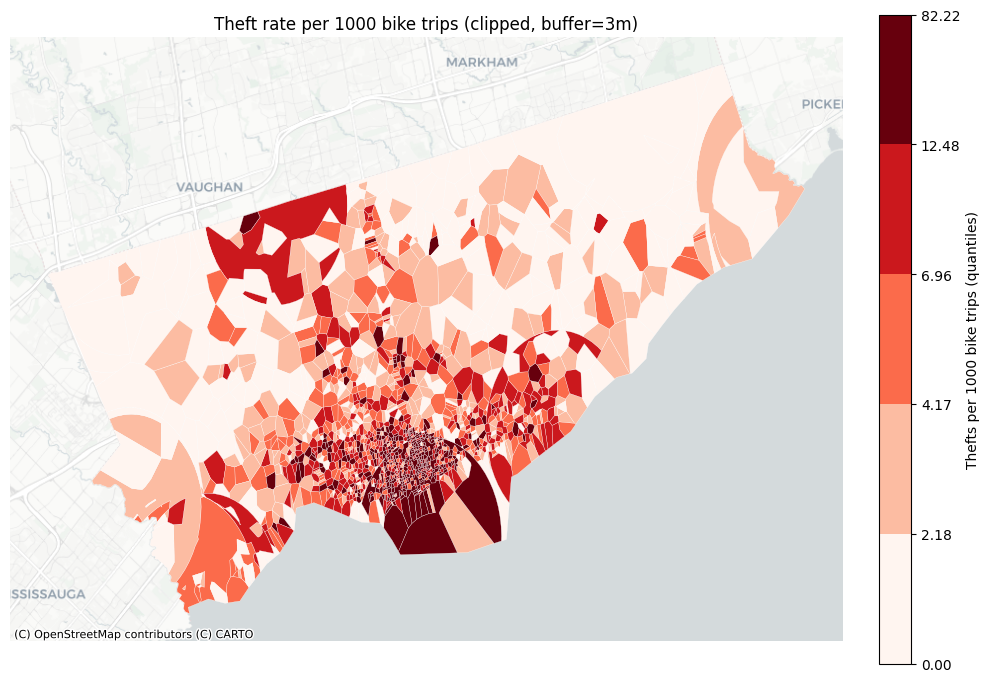

In [86]:
# Plot final clipped results (quantile color scaling, mask low-trip polygons) and save
if 'vor_final_plot' in globals():
    gdf = vor_final_plot.copy()
    gdf['plot_rate'] = gdf['theft_per_1000_trips']
    gdf['masked'] = gdf['bike_trips'] < MIN_BIKE_TRIPS
    n_masked = int(gdf['masked'].sum())
    print(f"Masking {n_masked} polygons with bike_trips < {MIN_BIKE_TRIPS}")

    proj = gdf.to_crs(epsg=3857)
    low = proj[proj['masked']].copy()
    main = proj[~proj['masked']].copy()
    main.loc[:, 'plot_rate_num'] = pd.to_numeric(main['plot_rate'], errors='coerce')
    vals = main['plot_rate_num'].dropna()

    from matplotlib.colors import BoundaryNorm
    cmap = plt.cm.Reds
    if len(vals) > 0 and vals.max() > 0:
        breaks = np.nanpercentile(vals, np.linspace(0, 100, N_QUANTILES + 1))
        breaks = np.unique(breaks).astype(float)
        if len(breaks) > 1:
            norm = BoundaryNorm(breaks, ncolors=cmap.N, clip=True)
        else:
            norm = plt.Normalize(vmin=vals.min(), vmax=vals.max())
    else:
        norm = None

    fig, ax = plt.subplots(figsize=(10,10))
    if len(low) > 0:
        low.plot(ax=ax, color="#efefef", edgecolor='#cccccc', linewidth=0.2, alpha=0.7)
    if len(main) > 0:
        try:
            if norm is not None:
                main.plot(column='plot_rate_num', ax=ax, cmap=cmap, norm=norm, linewidth=0.2, edgecolor='white')
            else:
                main.plot(column='plot_rate_num', ax=ax, cmap=cmap, linewidth=0.2, edgecolor='white')
        except Exception as e:
            print('Plotting failed, falling back to linear:', e)
            main.plot(column='plot_rate_num', ax=ax, cmap=cmap, linewidth=0.2, edgecolor='white')

    if norm is not None:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.036, pad=0.04)
        cbar.set_label('Thefts per 1000 bike trips (quantiles)')

    provider = None
    try:
        provider = ctx.providers.CartoDB.Positron
    except Exception:
        try:
            provider = ctx.providers.OpenStreetMap.Mapnik
        except Exception:
            provider = None
    if provider is not None:
        try:
            ctx.add_basemap(ax, source=provider)
        except Exception as e:
            print('Warning: could not add basemap:', e)

    plt.title(f"Theft rate per 1000 bike trips (clipped, buffer={BUFFER_NEG_M}m)")
    plt.axis('off')
    plt.tight_layout()

    png_name = OUT_DIR / f'voronoi_theft_rates_disjoint_bikeest_quantiles_clipped_buf{BUFFER_NEG_M}m.png'
    plt.savefig(png_name, dpi=150)
    print('Saved final plot to', png_name)
else:
    print('vor_final_plot not found; run final clipping cell first')

In [68]:
    nearest_map = gpd.sjoin_nearest(small_proj, large_proj[['vor_id','geometry']], how='left', distance_col='dist')
    # map small fragments to nearest large's vor_id (detect actual column name)
    vor_col_map = next((c for c in nearest_map.columns if 'vor_id' in c), None)
    if vor_col_map is None:
        raise RuntimeError('sjoin_nearest did not return a vor_id column; columns: %s' % (nearest_map.columns.tolist(),))
    mapping_small_to_large = pd.Series(nearest_map[vor_col_map].values, index=nearest_map.index).to_dict()
    small_frags['vor_id'] = small_frags.index.map(mapping_small_to_large)
    # combine and dissolve by vor_id
    combined = pd.concat([large_pieces, small_frags], ignore_index=True)

In [69]:
    nearest2 = gpd.sjoin_nearest(missing2_proj, vor_final_proj, how='left', distance_col='dist')
    vor_col2 = next((c for c in nearest2.columns if 'vor_id' in c), None)
    # create explicit mapping from original index to nearest vor_id and assign back
    mapping = pd.Series(nearest2[vor_col2].values, index=nearest2.index).to_dict()
    for orig_idx, vid in mapping.items():
        joined_final2.at[orig_idx, 'vor_id'] = vid

In [85]:
# Diagnostic: report theft totals to confirm reassignment
print('Source theft count (th_gdf):', len(th_gdf))
if 'vor_rates_final2' in globals():
    print('Vor final theft_count sum (vor_rates_final2):', int(vor_rates_final2['theft_count'].sum()))
if 'vor_rates_final' in globals():
    print('Vor final theft_count sum (vor_rates_final):', int(vor_rates_final['theft_count'].sum()))
if 'vor_rates_final_reassigned' in globals():
    print('Vor final reassigned theft sum (vor_rates_final_reassigned):', int(vor_rates_final_reassigned['theft_count'].sum()))

Source theft count (th_gdf): 39132
Vor final theft_count sum (vor_rates_final2): 38946
Vor final theft_count sum (vor_rates_final): 39132


In [75]:
vor_rates_final_reassigned = vor_final.merge(thft_final, left_on='vor_id', right_index=True, how='left')
vor_rates_final_reassigned = vor_rates_final_reassigned.merge(usage_final, left_on='vor_id', right_index=True, how='left')
vor_rates_final_reassigned['theft_count'] = vor_rates_final_reassigned['theft_count'].fillna(0).astype(int)
vor_rates_final_reassigned['bike_trips'] = vor_rates_final_reassigned['bike_trips'].fillna(0)
vor_rates_final_reassigned['theft_per_1000_trips'] = (vor_rates_final_reassigned['theft_count'] / vor_rates_final_reassigned['bike_trips'].replace({0: pd.NA})) * 1000
print('Post-reassign theft_count sum:', vor_rates_final_reassigned['theft_count'].sum())

# expose final variables for plotting (prefer reassigned version)
vor_final_plot = vor_rates_final_reassigned.copy()
print('Ready to plot using vor_final_plot (rows=%d)' % len(vor_final_plot))

NameError: name 'thft_final' is not defined

In [74]:
# Fix unmatched theft points by nearest disjoint polygon and recompute counts
joined = gpd.sjoin(th_gdf, vor_disjoint[['vor_id','geometry']], predicate='within', how='left')
missing = joined[joined['vor_id'].isna()].copy()
print("Missing thefts within disjoint polygons:", len(missing))
if len(missing) > 0:
    # use projected CRS for nearest computations
    missing_proj = missing.to_crs(epsg=3857)
    vor_proj = vor_disjoint.to_crs(epsg=3857)
    vor_proj_clean = vor_proj[['vor_id','geometry']].copy()
    # drop conflicting helper columns that may have been added earlier
    for col in ['index_right','index_left','level_0']:
        if col in missing_proj.columns:
            missing_proj = missing_proj.drop(columns=[col])
        if col in vor_proj_clean.columns:
            vor_proj_clean = vor_proj_clean.drop(columns=[col])
    nearest = gpd.sjoin_nearest(missing_proj, vor_proj_clean, how='left', distance_col='dist')
    print("nearest cols:", nearest.columns.tolist())
    print(nearest.head())
    # find column containing vor_id (some joins may rename it)
    vor_col = next((c for c in nearest.columns if 'vor_id' in c), None)
    if vor_col is None:
        raise RuntimeError("no vor_id column found in sjoin_nearest result")
    # assign vor_id for missing points using discovered column
    joined.loc[nearest.index, 'vor_id'] = nearest[vor_col].values
    print("Assigned nearest vor_id for missing points; sample assignments:")
    print(joined.loc[joined['vor_id'].notna()].head())

# compute theft counts per vor_id
thft = joined.groupby('vor_id').size().rename('theft_count')
# compute usage counts from TTS zones
if len(tts) > 0:
    if 'tts_weight_col' in globals() and tts_weight_col in tts.columns:
        u_join = gpd.sjoin(tts, vor_disjoint, predicate='intersects', how='left')
        usage = u_join.groupby('vor_id')[tts_weight_col].sum().rename('bike_trips')
    else:
        u_join = gpd.sjoin(tts, vor_disjoint, predicate='intersects', how='left')
        usage = u_join.groupby('vor_id').size().rename('bike_trips')
else:
    usage = pd.Series(dtype=float, name='bike_trips')

# merge counts into final results
result = vor_disjoint.merge(thft, left_on='vor_id', right_index=True, how='left')
result = result.merge(usage, left_on='vor_id', right_index=True, how='left')
result['theft_count'] = result['theft_count'].fillna(0).astype(int)
result['bike_trips'] = result['bike_trips'].fillna(0)
result['theft_per_1000_trips'] = (result['theft_count'] / result['bike_trips'].replace({0: pd.NA})) * 1000
print('Final totals: theft_count sum:', result['theft_count'].sum(), 'source thefts:', len(th_gdf))
vor_rates_disjoint = result

Missing thefts within disjoint polygons: 21
nearest cols: ['_id', 'EVENT_UNIQUE_ID', 'PRIMARY_OFFENCE', 'OCC_DATE', 'OCC_YEAR', 'OCC_MONTH', 'OCC_DOW', 'OCC_DAY', 'OCC_DOY', 'OCC_HOUR', 'REPORT_DATE', 'REPORT_YEAR', 'REPORT_MONTH', 'REPORT_DOW', 'REPORT_DAY', 'REPORT_DOY', 'REPORT_HOUR', 'DIVISION', 'LOCATION_TYPE', 'PREMISES_TYPE', 'BIKE_MAKE', 'BIKE_MODEL', 'BIKE_TYPE', 'BIKE_SPEED', 'BIKE_COLOUR', 'BIKE_COST', 'STATUS', 'LONG_WGS84', 'LAT_WGS84', 'geometry', 'vor_id_left', 'index_right', 'vor_id_right', 'dist']
       _id EVENT_UNIQUE_ID PRIMARY_OFFENCE   OCC_DATE OCC_YEAR OCC_MONTH  \
1828  1857  GO-20149005867     THEFT UNDER 2014-07-25     2014      July   
1910  1940  GO-20149005993     THEFT UNDER 2014-08-18     2014    August   
6284  6343  GO-20159011212     THEFT UNDER 2015-12-22     2015  December   
6306  6365  GO-20152226364     THEFT UNDER 2015-12-18     2015  December   
8553  8640  GO-20161438418             B&E 2016-08-15     2016    August   

      OCC_DOW OCC_DAY O

Masking 118 polygons with bike_trips < 10
Saved quantile-scaled masked GeoJSON and PNG to /run/media/kchanglani/2TB M.2 Volume/Documents/CodeRepos/parking-map-data/notebooks/notebooks/output/voronoi_theft


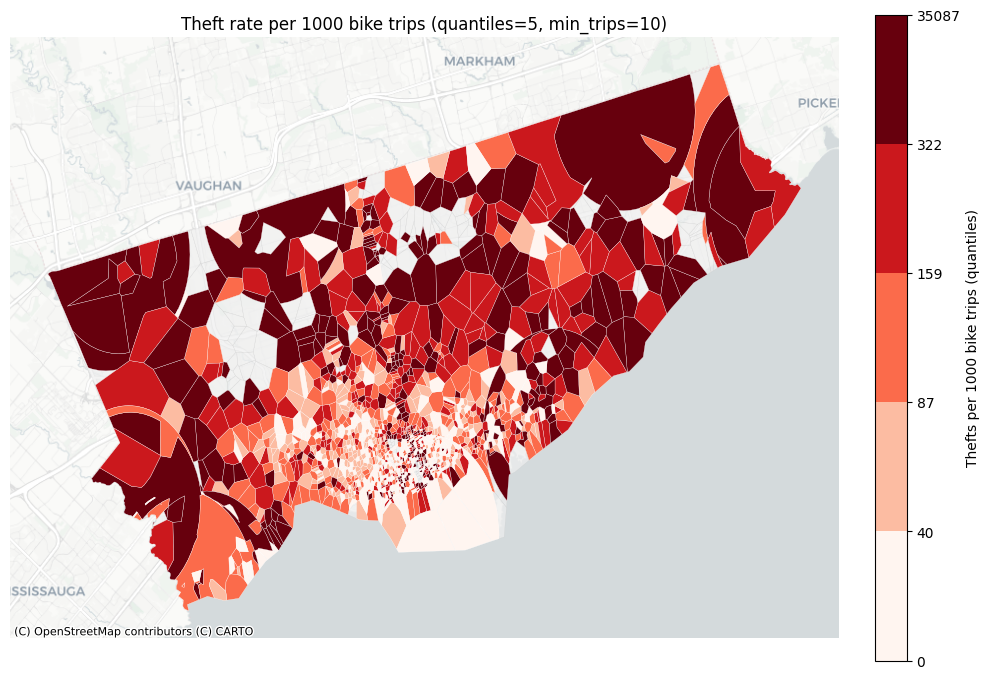

In [76]:
# Plot the disjoint Voronoi aggregated rates (quantile color scaling + sliver removal mask) and save outputs
# Visual parameters
MIN_BIKE_TRIPS = 10  # mask polygons with fewer than this many bike trips
N_QUANTILES = 5      # number of quantile bins for color scaling

# choose cleaned or original aggregated results (prefer cleaned if available)
if 'vor_rates_clean_bikeest' in globals():
    gdf = vor_rates_clean_bikeest.copy()
elif 'vor_rates_clean' in globals():
    gdf = vor_rates_clean.copy()
elif 'vor_rates_disjoint_bikeest' in globals():
    gdf = vor_rates_disjoint_bikeest.copy()
else:
    gdf = vor_rates_disjoint.copy()

# ensure we have the plotting columns
gdf = gdf.copy()
gdf['plot_rate'] = gdf['theft_per_1000_trips']
gdf['masked'] = gdf['bike_trips'] < MIN_BIKE_TRIPS
n_masked = int(gdf['masked'].sum())
print(f"Masking {n_masked} polygons with bike_trips < {MIN_BIKE_TRIPS}")

# project for accurate rendering/area
proj = gdf.to_crs(epsg=3857)
low = proj[proj['masked']].copy()
main = proj[~proj['masked']].copy()

# coerce to numeric to avoid object dtype issues
main.loc[:, 'plot_rate_num'] = pd.to_numeric(main['plot_rate'], errors='coerce')
vals = main['plot_rate_num'].dropna()

# compute quantile breaks on the unmasked numeric values
from matplotlib.colors import BoundaryNorm
cmap = plt.cm.Reds
if len(vals) > 0 and vals.max() > 0:
    breaks = np.nanpercentile(vals, np.linspace(0, 100, N_QUANTILES + 1))
    breaks = np.unique(breaks).astype(float)
    if len(breaks) > 1:
        norm = BoundaryNorm(breaks, ncolors=cmap.N, clip=True)
    else:
        norm = plt.Normalize(vmin=vals.min(), vmax=vals.max())
else:
    norm = None

fig, ax = plt.subplots(figsize=(10, 10))
# plot low-volume polygons in light grey
if len(low) > 0:
    low.plot(ax=ax, color="#efefef", edgecolor='#cccccc', linewidth=0.2, alpha=0.7)
# plot main polygons with quantile normalization
if len(main) > 0:
    try:
        if norm is not None:
            main.plot(column='plot_rate_num', ax=ax, cmap=cmap, norm=norm, linewidth=0.2, edgecolor='white')
        else:
            main.plot(column='plot_rate_num', ax=ax, cmap=cmap, linewidth=0.2, edgecolor='white')
    except Exception as e:
        print('Plotting with quantiles failed, falling back to linear:', e)
        main.plot(column='plot_rate_num', ax=ax, cmap=cmap, linewidth=0.2, edgecolor='white')

# add colorbar legend (quantile labels)
if norm is not None:
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.036, pad=0.04)
    cbar.set_label('Thefts per 1000 bike trips (quantiles)')

# add basemap with fallbacks
provider = None
try:
    provider = ctx.providers.CartoDB.Positron
except Exception:
    try:
        provider = ctx.providers.OpenStreetMap.Mapnik
    except Exception:
        provider = None
if provider is not None:
    try:
        ctx.add_basemap(ax, source=provider)
    except Exception as e:
        print("Warning: could not add basemap:", e)

plt.title(f"Theft rate per 1000 bike trips (quantiles={N_QUANTILES}, min_trips={MIN_BIKE_TRIPS})")
plt.axis('off')
plt.tight_layout()

# Save outputs (update filenames to reflect quantile + sliver removal)
OUT_DIR.mkdir(parents=True, exist_ok=True)
# mark masked flag in saved geojson
# save the cleaned (sliver-removed) version if available
if 'vor_rates_clean' in globals():
    save_gdf = vor_rates_clean.copy()
else:
    save_gdf = gdf.copy()
save_gdf.to_file(OUT_DIR / 'voronoi_theft_rates_disjoint_bikeest_quantiles_slivers_removed.geojson', driver='GeoJSON')
plt.savefig(OUT_DIR / 'voronoi_theft_rates_disjoint_bikeest_quantiles_slivers_removed.png', dpi=150)
print('Saved quantile-scaled masked GeoJSON and PNG to', OUT_DIR)

In [11]:
# Inspect the package resources for bicycle-thefts to find usable resource URL
import requests
from bikespace_data.resources.toronto_open_data import PACKAGE_URL
meta = requests.get(PACKAGE_URL, params={"id": "bicycle-thefts"}).json()
for rs in meta['result']['resources']:
    print(rs['id'], rs.get('format'), rs.get('url'))

34e4206d-549e-4957-a0da-093d703a1c62 GeoJSON https://ckan0.cf.opendata.inter.prod-toronto.ca/datastore/dump/34e4206d-549e-4957-a0da-093d703a1c62
5432bcad-59c4-4e07-b2c7-72ecd1f02258 gpkg https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/c7d34d9b-23d2-44fe-8b3b-cd82c8b38978/resource/5432bcad-59c4-4e07-b2c7-72ecd1f02258/download/bicycle-thefts-4326.gpkg
ca26d290-7caa-4232-8ab3-f83ea8eaa24c GPKG https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/c7d34d9b-23d2-44fe-8b3b-cd82c8b38978/resource/ca26d290-7caa-4232-8ab3-f83ea8eaa24c/download/bicycle-thefts-2945.gpkg
55136dac-26b1-4028-b9f5-7c2344f94153 CSV https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/c7d34d9b-23d2-44fe-8b3b-cd82c8b38978/resource/55136dac-26b1-4028-b9f5-7c2344f94153/download/bicycle-thefts-4326.csv
fc64d996-867f-45d1-8940-80710f7d9cab CSV https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/c7d34d9b-23d2-44fe-8b3b-cd82c8b38978/resource/fc64d996-867f-45d1-8940-80710f7d9cab/download/bicycle-thefts-2945.csv

In [12]:
# Fetch the GeoJSON downloadable resource directly (prefer resources ending with .geojson)
from bikespace_data.resources.toronto_open_data import PACKAGE_URL
meta = requests.get(PACKAGE_URL, params={"id": "bicycle-thefts"}).json()
# prefer geojson download links
cands = [rs for rs in meta['result']['resources'] if rs.get('format','').lower() == 'geojson' and rs.get('url','').lower().endswith('.geojson')]
if cands:
    url = cands[0]['url']
else:
    # fallback to first geojson or any url
    cands_all = [rs for rs in meta['result']['resources'] if rs.get('format','').lower() == 'geojson']
    url = cands_all[0]['url'] if cands_all else meta['result']['resources'][0]['url']

print('Using URL:', url)

th_gdf = gpd.read_file(url).convert_dtypes()
th_gdf = th_gdf.to_crs(epsg=4326)
out = Path('bicycle_theft') / 'output_files'
out.mkdir(parents=True, exist_ok=True)
th_gdf.to_file(out / 'bicycle-thefts-normalized.geojson', driver='GeoJSON')
print(f"Saved {len(th_gdf)} thefts to {out / 'bicycle-thefts-normalized.geojson'}")

Using URL: https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/c7d34d9b-23d2-44fe-8b3b-cd82c8b38978/resource/e7fe6133-17d8-4a39-88af-352440dec684/download/bicycle-thefts-4326.geojson
Saved 39473 thefts to bicycle_theft/output_files/bicycle-thefts-normalized.geojson
